# Symbolic computation

function: 


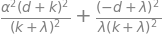

------------------------------------------------------------
first diff. on d: 


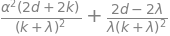

second diff. on d: 


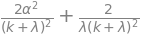

------------------------------------------------------------
first diff. on k: 


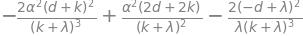

second diff. on k: 


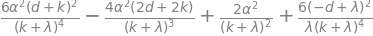

------------------------------------------------------------
first diff. on k, then second diff. on d: 


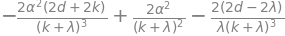

In [1]:
"""
Source:
Yasin Asar. (2017). Some new methods to solve multicollinearity in logistic regression.
Communications in Statistics - Simulation and Computation, 46:4, 2576-2586. Section 2 and 2.2 (page 2578-2579)
"""

import sympy as sp
from IPython.display import display

# define symbol
d, k, λ, α = sp.symbols("d k lambda alpha")

# define funtion
expr = ((λ - d) ** 2 / (λ * (λ + k) ** 2)) + ((d + k) ** 2 * α**2 / (λ + k) ** 2)

# first derivative
diff_d = sp.diff(expr, d)
diff_k = sp.diff(expr, k)

# second derivative
second_diff_d = sp.diff(diff_d, d)
second_diff_k = sp.diff(diff_k, k)
second_diff_d_k = sp.diff(diff_k, d)

# show the function in LATEX format
sp.init_printing()

# print results
print("function: ")
display(expr)

print("-" * 60)
print("first diff. on d: ")
display(diff_d)
print("second diff. on d: ")
display(second_diff_d)

print("-" * 60)
print("first diff. on k: ")
display(diff_k)
print("second diff. on k: ")
display(second_diff_k)

print("-" * 60)
print(f"first diff. on k, then second diff. on d: ")
display(second_diff_d_k)

solve the system of equations between the first diff. on d and k: 


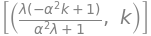

In [2]:
# solve the system of equations
sol = sp.solve((diff_d, diff_k), d, k)

print("solve the system of equations between the first diff. on d and k: ")
display(sol)

# Numerical computation

In [3]:
import numpy as np
from numpy import linalg as LA
from Data_generation_asar import generate_asar_data
from MLE_asar import MLE
from LLT_asar import k_estimator


def LLT(X, beta_MLE, X_TWX, k_type):
    """
    Input
    - X            : Feature
    - beta_MLE     : Optimal beta received by using Maximum Likelihood Estimation
    - X_TWX        : Marix X^T @ W @ X
    - k_type       : Type of estimator k for Logistic Liu-type Estimation

    Output
    - beta_LLT     : Optimal beta obtained using Logistic Liu-type Estimation
    - alpha        : Eigenvectors of X_TWX dot beta_MLE
    - lambda_vals  : Eigenvalues of X_TWX
    - d_initial    : The initial parameter d
    - d            : Parameter d after compute
    - k            : Parameter k after compute

    Source
    - Yasin Asar. (2017). Some new methods to solve multicollinearity in logistic regression.
    Communications in Statistics - Simulation and Computation, 46:4, 2576-2586. Section 2 and 2.2 (page 2578-2579)
    """
    _, p = X.shape
    beta_LLT = np.zeros(p)

    # Eigenvalues and eigenvectors
    lambda_vals, Q = LA.eigh(X_TWX)

    # Compute alpha = Q.T @ beta_MLE (page 2581)
    alpha = Q.T @ beta_MLE
    d_initial = np.min(lambda_vals / (1 + lambda_vals * alpha**2))
    d = np.random.uniform(d_initial / 2, d_initial)

    iteration = 0
    while not np.all(d < lambda_vals / (1 + lambda_vals * alpha**2)):
        d -= 1e-10
        iteration += 1

    k_LT1 = (lambda_vals - d * (1 + lambda_vals * alpha**2)) / (lambda_vals * alpha**2)

    k = k_estimator(k_type, k_LT1, p)

    beta_LLT = LA.inv(X_TWX + k * np.eye(p)) @ (X_TWX - d * np.eye(p)) @ beta_MLE

    # print(f"Iteration {iteration} times for {k_type}: d = {d}, k = {k}")

    return beta_LLT, alpha, lambda_vals, d_initial, k, d


# Settings for each dataset in Table 1 to Table 4 (page 2581)
n_values = [50]
p_values = [4]
rho2_values = [0.90]
tolerance = 1e-7
num_simulations = 1


base_seed = 426
rng_seed_generator = np.random.default_rng(base_seed)
seeds = rng_seed_generator.integers(low=0, high=500000, size=500000)


# Start simulation
setting_index, test_num = 0, 0
for p in p_values:
    for rho2 in rho2_values:
        for n in n_values:
            for sim in range(num_simulations):
                # print(f"simulation: {sim+1}")
                X, y, beta_true, _ = generate_asar_data(
                    n, p, rho2, seed=seeds[setting_index + sim], setting_index=sim
                )

                beta_MLE, X_TWX = MLE(X, y, tolerance, setting_index)
                (
                    beta_LLT_k_AM,
                    alpha_vals,
                    lambda_vals,
                    d_initial,
                    k_return,
                    d_return,
                ) = LLT(X, beta_MLE, X_TWX, "AM")
                print(f"alpha_vals: {alpha_vals}")
                print(f"lambda_vals: {lambda_vals}")
                print(f"d_initial: {d_initial}")
                print(f"k_return: {k_return}")
                print(f"d_return: {d_return}")

alpha_vals: [ 0.05808821  0.74000201 -0.43772453 -0.31946219  0.1076296 ]
lambda_vals: [ 0.61961124  0.99805265  1.23315893  1.44953246 61.13868626]
d_initial: 0.6183185123907263
k_return: 29.814050355446852
d_return: 0.5034013172960061


alpha_val: 0.05808820786735064, lambda_val: 0.6196112413968416
the best combination of d and k: [(0.616789409155899, 0.732906548141274)]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
alpha_val: 0.7400020148099088, lambda_val: 0.998052650906814
the best combination of d and k: [(0.698767574771643, -0.151164592848921)]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
alpha_val: -0.4377245257525792, lambda_val: 1.2331589326271881
the best combination of d and k: [(-15.2948847023923, 85.2469652238639)]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
alpha_val: -0.3194621908184222, lambda_val: 1.4495324583890674
the best combination of d and k: [(1.29893408796982, -0.280920917826978)]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
alpha_val: 0.1076296035810566, lambda_val: 61.138686256078664
the best combination of d and k: [(-44.7426811551556, 194.2422560021

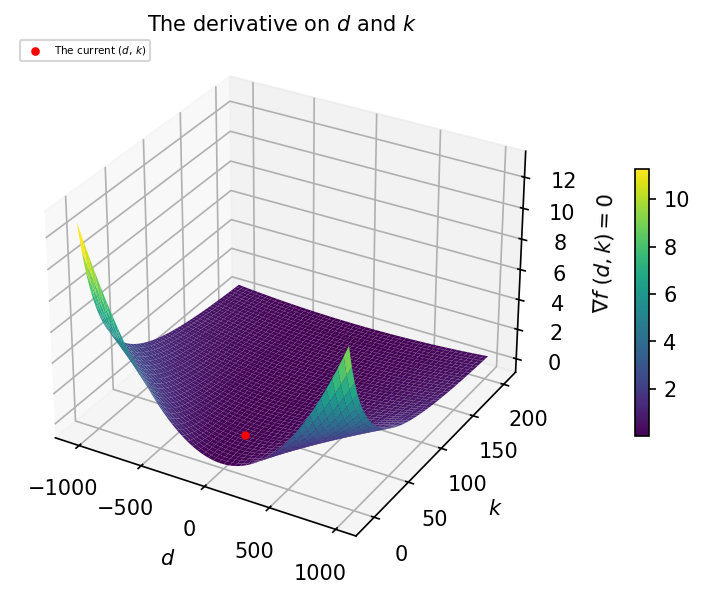

In [4]:
import matplotlib.pyplot as plt

d, k = sp.symbols("d k")

solutions_list = []
for i in range(len(alpha_vals)):
    α = alpha_vals[i]
    λ = lambda_vals[i]

    # define function
    expr = ((λ - d) ** 2 / (λ * (λ + k) ** 2)) + ((d + k) ** 2 * α**2 / (λ + k) ** 2)

    # first derivative
    diff_d = sp.diff(expr, d)
    diff_k = sp.diff(expr, k)

    # solve system of equations, let the first derivative equal to 0
    solutions = sp.solve([diff_d, diff_k], (d, k))
    solutions_list.append(solutions)

    print(f"alpha_val: {α}, lambda_val: {λ}")
    print("the best combination of d and k:", solutions)
    print("- - " * 20)

# Set the plotting area dynamically
all_d_values = [sol[0][0] for sol in solutions_list]
all_k_values = [sol[0][1] for sol in solutions_list]
min_d, max_d = float(min(all_d_values)) - 1000, float(max(all_d_values)) + 1000
min_k, max_k = float(min(all_k_values)) - 10, float(max(all_k_values)) + 10

d_vals = np.linspace(min_d, max_d, 500)
k_vals = np.linspace(min_k, max_k, 500)
d_grid, k_grid = np.meshgrid(d_vals, k_vals)

# Compute the value in the area
expr_func = sp.lambdify((d, k), expr, "numpy")
expr_vals = expr_func(d_grid, k_grid)

# Plot the figure
plt.style.use("default")
fig = plt.figure(figsize=(6, 4), dpi=150)

# Plot 3D surface
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(d_grid, k_grid, expr_vals, cmap="viridis", zorder=1)
z_val = expr_func(float(d_return), float(k_return))

# Plot the current point return now
ax.scatter(
    d_return, k_return, z_val, color="r", s=10, label="The current ($d$, $k$)", zorder=2
)
ax.plot(d_return, k_return, z_val, color="r", marker="o", markersize=3, zorder=10)

# Add colorbar of the surface
fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

ax.set_title("The derivative on $d$ and $k$", size=10, pad=0.1)
ax.set_xlabel("$d$")
ax.set_ylabel("$k$")
ax.set_zlabel("$\\nabla f \ (d, k) = 0$")
ax.legend(loc="upper left", fontsize=5)

fig.tight_layout()
plt.show()
plt.close()